<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/04/neural-network/RNN/Project_05_TextClassification_LSTM_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM, Embedding
from tensorflow.keras.models import Model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/NLP-course/Course Material/Recurrent Neural Network ( RNN )

/content/drive/MyDrive/NLP-course/Course Material/Recurrent Neural Network ( RNN )


# Read the Data

In [4]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')   # encoding='ISO-8859-1' encodes "Latin alphabet no. 1",
                                                      #consisting of 191 characters from the Latin script.

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

# Drop Irrelevant Features

In [7]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5572, 2)

# Check for Null Values

In [10]:
df.isnull().any()

,0
v1,False
v2,False


# Rename the columns

In [11]:
df.columns = ['labels', 'Text']

In [12]:
df.head()

,labels,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Transform labels to integers

In [13]:
df['labels'] = df['labels'].map({'ham': 0, 'spam': 1})

In [14]:
df.head()

,labels,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
y = df['labels'].values
y.shape

(5572,)

In [16]:
y

array([0, 0, 1, ..., 0, 0, 0])

# Perform data Splitting

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df['Text'], y, test_size = 0.2, random_state = 42)

# Convert sentences to sequences

In [18]:
vocab_size = 20000
tokenizer = Tokenizer(num_words = vocab_size)
tokenizer.fit_on_texts(X_train)
sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test = tokenizer.texts_to_sequences(X_test)

# Perform word to index mapping

In [19]:
word2idx = tokenizer.word_index
V = len(word2idx)
print('Found %s unique tokens.' % V)

Found 7954 unique tokens.


# Sequence padding to get N X T Matrix

In [20]:
trainX = pad_sequences(sequences_train)
print('Shape of train tensor:', trainX.shape)

Shape of train tensor: (4457, 121)


# Set seq_len OR timesteps

In [21]:
T = trainX.shape[1]
print(T)

121


# Padding Test data

In [22]:
testX = pad_sequences(sequences_test, maxlen=T)
print('Shape of test tensor:', testX.shape)

Shape of test tensor: (1115, 121)


# Create LSTM Model for Text Classification

In [23]:
D = 20  # Set the dimension of embeddings

H = 15 # Hidden state dimensions

i = Input(shape=(T, ))
x = Embedding(V + 1, D)(i) # This is N x T x D array. (V + 1) because we started from index 1
x = LSTM(H, return_sequences=True)(x)
print(x.shape)                       # N x T x H # Batchsize x steps x features
x = GlobalMaxPooling1D()(x)
print(" ")
print(x.shape)                       # N x H  # Batchsize x features
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

(None, 121, 15)
 
(None, 15)


# Compile the Model

In [24]:
model.compile( loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'] )

# Train the Model

In [25]:
hist = model.fit(
  trainX,
  y_train,
  epochs=10,
  validation_data=(testX, y_test)
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8595 - loss: 0.3851 - val_accuracy: 0.8655 - val_loss: 0.2602
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9542 - loss: 0.1414 - val_accuracy: 0.9740 - val_loss: 0.0998
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9897 - loss: 0.0543 - val_accuracy: 0.9803 - val_loss: 0.0742
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9946 - loss: 0.0290 - val_accuracy: 0.9830 - val_loss: 0.0731
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9973 - loss: 0.0174 - val_accuracy: 0.9839 - val_loss: 0.0701
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9982 - loss: 0.0109 - val_accuracy: 0.9785 - val_loss: 0.0719
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9993 - loss: 0.0068 - val_accuracy: 0.9821 - val_loss: 0.0832
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9998 - loss: 0.0049 - val_acc

# Visualizing the Performance of Model

In [26]:
trainAcc = [100 * x for x in hist.history['accuracy']]
testAcc = [100 * x for x in hist.history['val_accuracy']]

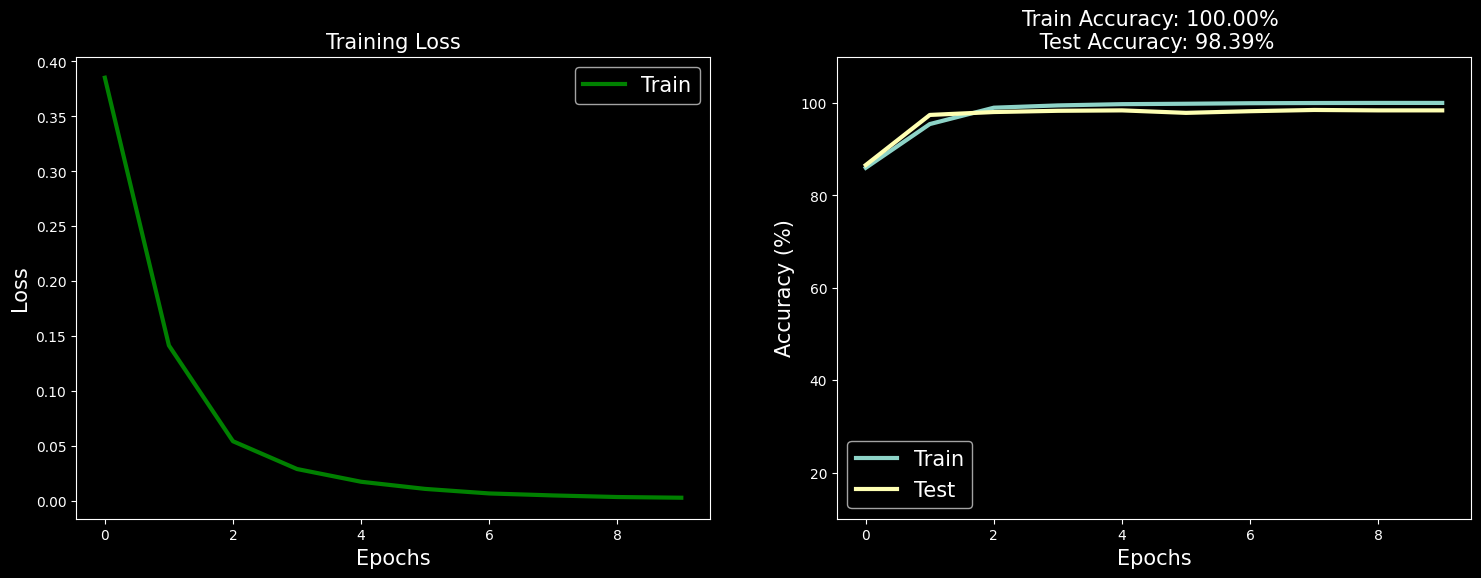

In [27]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(hist.history['loss'], 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)


ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()